In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import glob
import re

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler,
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from typing import Dict
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
import warnings

     
from sklearn.metrics import (
    roc_auc_score, 
    roc_curve, 
    confusion_matrix, 
    precision_score, 
    recall_score, 
    accuracy_score,
    classification_report
)

warnings.filterwarnings('ignore')


# import warnings
# warnings.filterwarnings('ignore')


In [2]:
def rows_n_hours_before_failure(machine, machine_failure, hours):  
    failure_times = machine_failure["datetime"]

    # Convert the datetime columns to datetime if they're not already
    machine["datetime"] = pd.to_datetime(machine["datetime"])
    failure_times = pd.to_datetime(failure_times)

    # Initialize an empty list to store the rows and their indices
    rows = []
    indices = []

    # Iterate over each failure time and its index
    for idx_failure, failure_time in zip(machine_failure.index, failure_times):
        # Calculate the time n hours before the failure
        target_time = failure_time - pd.Timedelta(hours=hours)
        
        # Get the row with the closest time to the target time
        idx = (machine["datetime"] - target_time).abs().idxmin()
        closest_row = machine.loc[idx]
        
        # Append the row and the failure index to the lists
        rows.append(closest_row)
        indices.append(idx_failure)

    # Create a new dataframe with the rows
    machine_1_prev_24h = pd.DataFrame(rows)
    machine_1_prev_24h["id_failure_row"] = indices

    return machine_1_prev_24h


def update_lag_failure_target(machine_failure, machine_n_hours_before_failure, lag_failure):
    """
    Updates the 'target' variable in lag_failure with the corresponding 'failure' value from machine_failure,
    using machine_n_hours_before_failure as a bridge for the join.
    """
    if 'id_failure_row' not in machine_n_hours_before_failure.columns:
        raise ValueError("machine_n_hours_before_failure must have 'id_failure_row' column.")

    failure_values = []
    for idx in lag_failure.index:
        if idx in machine_n_hours_before_failure.index:
            id_failure_row = machine_n_hours_before_failure.loc[idx, 'id_failure_row']
            # If multiple rows, take the first
            if isinstance(id_failure_row, pd.Series):
                id_failure_row = id_failure_row.iloc[0]
            failure_val = machine_failure.loc[id_failure_row, 'failure'] if id_failure_row in machine_failure.index else None
        else:
            failure_val = None
        failure_values.append(failure_val)

    lag_failure = lag_failure.copy()
    lag_failure['target'] = failure_values
    return lag_failure


def create_safe_non_failure_samples_enhanced(machine_lag, lag_failure_updated, hours_before=24, safe_buffer_hours=48):
    """
    Create non-failure samples from 'safe zones' using the full feature set from machine_lag
    
    Parameters:
    - machine_lag: Full dataset with all engineered features
    - lag_failure_updated: Your target dataset (24h before failures)
    - hours_before: Lead time before failure (24h)
    - safe_buffer_hours: Additional buffer to ensure truly safe periods (48h recommended)
    """
    
    # Convert datetime columns to datetime if they aren't already
    machine_lag['datetime'] = pd.to_datetime(machine_lag['datetime'])
    lag_failure_updated['datetime'] = pd.to_datetime(lag_failure_updated['datetime'])
    
    # Get all failure timestamps from machine_lag where failure = 1
    failure_timestamps = machine_lag[machine_lag['failure'] == 1]['datetime']
    
    # Create exclusion zones around each failure
    exclusion_periods = []
    
    for failure_time in failure_timestamps:
        # Exclude from (failure_time - safe_buffer_hours) to failure_time
        start_exclusion = failure_time - pd.Timedelta(hours=safe_buffer_hours)
        end_exclusion = failure_time
        exclusion_periods.append((start_exclusion, end_exclusion))
    
    # Also exclude the timestamps that are already in lag_failure_updated (24h before failures)
    existing_target_timestamps = set(lag_failure_updated['datetime'])
    
    # Filter machine_lag to find safe timestamps
    safe_candidates = machine_lag.copy()
    
    # Remove rows that fall in exclusion zones
    def is_in_exclusion_zone(timestamp):
        for start_excl, end_excl in exclusion_periods:
            if start_excl <= timestamp <= end_excl:
                return True
        return False
    
    # Filter out exclusion zones and existing target timestamps
    safe_mask = (
        ~safe_candidates['datetime'].apply(is_in_exclusion_zone) &
        ~safe_candidates['datetime'].isin(existing_target_timestamps) &
        (safe_candidates['failure'] == 0)  # Only non-failure records
    )
    
    safe_candidates = safe_candidates[safe_mask]
    
    if len(safe_candidates) == 0:
        print("Warning: No safe candidates found. Consider reducing safe_buffer_hours.")
        return pd.DataFrame()
    
    # Sample non-failure records
    n_samples = min(len(lag_failure_updated), len(safe_candidates))
    
    if n_samples > len(safe_candidates):
        print(f"Warning: Only {len(safe_candidates)} safe candidates available, but {len(lag_failure_updated)} samples requested.")
        n_samples = len(safe_candidates)
    
    # Randomly sample from safe candidates
    non_failure_samples = safe_candidates.sample(n=n_samples, random_state=42).copy()
    
    # Set target to 0 for non-failure samples (they should already be 0, but ensure it)
    non_failure_samples['target'] = 0
    
    # Reset index
    non_failure_samples = non_failure_samples.reset_index(drop=True)
    
    return non_failure_samples

def create_balanced_dataset(machine_lag, lag_failure_updated, hours_before=24, safe_buffer_hours=48):
    """
    Create a balanced dataset combining failure predictions and safe non-failure samples
    """
    
    # Get non-failure samples
    non_failure_df = create_safe_non_failure_samples_enhanced(machine_lag, lag_failure_updated, hours_before, safe_buffer_hours)
    
    if len(non_failure_df) == 0:
        return lag_failure_updated.copy()
    
    # Ensure both dataframes have the same columns
    common_columns = list(set(lag_failure_updated.columns) & set(non_failure_df.columns))
    
    # If lag_failure_updated is missing some features, we need to merge them from machine_lag
    if len(common_columns) < len(machine_lag.columns):
        print("Merging additional features from machine_lag to lag_failure_updated...")
        
        # Merge lag_failure_updated with machine_lag to get all features
        lag_failure_enhanced = pd.merge(
            lag_failure_updated, 
            machine_lag, 
            on='datetime', 
            how='left',
            suffixes=('', '_from_machine_lag')
        )
        
        # Clean up duplicate columns (keep the original values from lag_failure_updated)
        for col in lag_failure_enhanced.columns:
            if col.endswith('_from_machine_lag'):
                original_col = col.replace('_from_machine_lag', '')
                if original_col in lag_failure_enhanced.columns:
                    lag_failure_enhanced[original_col] = lag_failure_enhanced[original_col].fillna(
                        lag_failure_enhanced[col]
                    )
                    lag_failure_enhanced = lag_failure_enhanced.drop(columns=[col])
        
        lag_failure_to_use = lag_failure_enhanced
    else:
        lag_failure_to_use = lag_failure_updated.copy()
    
    # Ensure all required columns are present in both dataframes
    all_required_columns = list(machine_lag.columns)
    
    # Add missing columns with appropriate default values if needed
    for col in all_required_columns:
        if col not in lag_failure_to_use.columns:
            lag_failure_to_use[col] = np.nan
        if col not in non_failure_df.columns:
            non_failure_df[col] = np.nan
    
    # Select only the required columns in the same order
    lag_failure_to_use = lag_failure_to_use[all_required_columns]
    non_failure_df = non_failure_df[all_required_columns]
    
    # Combine datasets
    balanced_dataset = pd.concat([lag_failure_to_use, non_failure_df], ignore_index=True)
    balanced_dataset = balanced_dataset.sort_values('datetime').reset_index(drop=True)
    
    return balanced_dataset, non_failure_df


# Alternative: If you want more control over sampling strategy
def create_stratified_non_failure_samples(machine_lag, lag_failure_updated, safe_buffer_hours=48, stratify_by=['comp', 'is_weekend', 'is_working_hours']):
    """
    Create stratified non-failure samples to ensure diversity across different conditions
    """
    
    machine_lag['datetime'] = pd.to_datetime(machine_lag['datetime'])
    lag_failure_updated['datetime'] = pd.to_datetime(lag_failure_updated['datetime'])
    
    # Get failure timestamps and create exclusion zones
    failure_timestamps = machine_lag[machine_lag['failure'] == 1]['datetime']
    exclusion_periods = []
    
    for failure_time in failure_timestamps:
        start_exclusion = failure_time - pd.Timedelta(hours=safe_buffer_hours)
        end_exclusion = failure_time
        exclusion_periods.append((start_exclusion, end_exclusion))
    
    # Filter safe candidates
    def is_in_exclusion_zone(timestamp):
        for start_excl, end_excl in exclusion_periods:
            if start_excl <= timestamp <= end_excl:
                return True
        return False
    
    existing_target_timestamps = set(lag_failure_updated['datetime'])
    
    safe_mask = (
        ~machine_lag['datetime'].apply(is_in_exclusion_zone) &
        ~machine_lag['datetime'].isin(existing_target_timestamps) &
        (machine_lag['failure'] == 0)
    )
    
    safe_candidates = machine_lag[safe_mask].copy()
    
    if len(safe_candidates) == 0:
        return pd.DataFrame()
    
    # Stratified sampling
    target_samples = len(lag_failure_updated)
    
    # Get the distribution of stratification variables in lag_failure_updated
    if all(col in lag_failure_updated.columns for col in stratify_by):
        # Sample proportionally to match the failure sample distribution
        stratified_samples = []
        
        for group_values, group_df in lag_failure_updated.groupby(stratify_by):
            group_size = len(group_df)
            proportion = group_size / len(lag_failure_updated)
            target_group_size = int(proportion * target_samples)
            
            # Find matching safe candidates
            mask = pd.Series(True, index=safe_candidates.index)
            for i, col in enumerate(stratify_by):
                mask &= (safe_candidates[col] == group_values[i])
            
            group_safe_candidates = safe_candidates[mask]
            
            if len(group_safe_candidates) > 0:
                sample_size = min(target_group_size, len(group_safe_candidates))
                group_sample = group_safe_candidates.sample(n=sample_size, random_state=42)
                stratified_samples.append(group_sample)
        
        if stratified_samples:
            non_failure_samples = pd.concat(stratified_samples, ignore_index=True)
        else:
            # Fallback to random sampling
            non_failure_samples = safe_candidates.sample(
                n=min(target_samples, len(safe_candidates)), 
                random_state=42
            )
    else:
        # Fallback to random sampling if stratification columns not available
        non_failure_samples = safe_candidates.sample(
            n=min(target_samples, len(safe_candidates)), 
            random_state=42
        )
    
    non_failure_samples['target'] = 0
    return non_failure_samples.reset_index(drop=True)

In [3]:
# Loop through machine_number 1 to 100 and generate balanced datasets for each machine


hours_before_failure = 24
safe_buffer_hours = 48

balanced_datasets = {}
non_failure_dfs = {}

for machine_number in range(1, 101):
    try:
        # Load data for this machine
        machine = pd.read_csv(f"../../../data/azure_pm/machines/machine_{machine_number}.csv")
        machine_lag = pd.read_csv(f"../../../data/azure_pm/lag_features/machine_{machine_number}_lag_features.csv")

        # Identify failures
        machine_failure = machine[machine['failure'] != '0']

        # Get rows n hours before each failure
        machine_n_hours_before_failure = rows_n_hours_before_failure(machine=machine,machine_failure=machine_failure,hours=hours_before_failure)
        lag_failure = rows_n_hours_before_failure(machine=machine_lag,machine_failure=machine_lag[machine_lag['failure'] != 0], hours=hours_before_failure)

        # Update lag_failure target
        lag_failure_updated = update_lag_failure_target(machine_failure=machine_failure, machine_n_hours_before_failure=machine_n_hours_before_failure, lag_failure=lag_failure)

        # Create balanced dataset
        balanced_dataset, non_failure_df = create_balanced_dataset(machine_lag=machine_lag, 
                                                                   lag_failure_updated=lag_failure_updated, 
                                                                   hours_before=hours_before_failure, 
                                                                   safe_buffer_hours=safe_buffer_hours)

        # Store results with machine number as key
        balanced_datasets[machine_number] = balanced_dataset
        non_failure_dfs[machine_number] = non_failure_df

        print(f"✅ Machine {machine_number}: Balanced dataset shape: {balanced_dataset.shape}, Non-failure shape: {non_failure_df.shape}")

    except Exception as e:
        print(f"❌ Machine {machine_number}: Error - {e}")

✅ Machine 1: Balanced dataset shape: (22, 65), Non-failure shape: (11, 65)
✅ Machine 2: Balanced dataset shape: (12, 65), Non-failure shape: (6, 65)
✅ Machine 3: Balanced dataset shape: (10, 65), Non-failure shape: (5, 65)
✅ Machine 4: Balanced dataset shape: (14, 65), Non-failure shape: (7, 65)
✅ Machine 5: Balanced dataset shape: (20, 65), Non-failure shape: (10, 65)
❌ Machine 6: Error - 'datetime'
✅ Machine 7: Balanced dataset shape: (34, 65), Non-failure shape: (17, 65)
✅ Machine 8: Balanced dataset shape: (10, 65), Non-failure shape: (5, 65)
✅ Machine 9: Balanced dataset shape: (32, 65), Non-failure shape: (16, 65)
✅ Machine 10: Balanced dataset shape: (16, 65), Non-failure shape: (8, 65)
✅ Machine 11: Balanced dataset shape: (18, 65), Non-failure shape: (9, 65)
✅ Machine 12: Balanced dataset shape: (18, 65), Non-failure shape: (9, 65)
✅ Machine 13: Balanced dataset shape: (44, 65), Non-failure shape: (22, 65)
✅ Machine 14: Balanced dataset shape: (14, 65), Non-failure shape: (7, 

In [7]:
balanced_datasets[78]

,datetime,volt,rotate,pressure,vibration,errorID,comp,failure,target,volt_lag_1h,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
0,2015-01-14 12:00:00,0.471413,0.287691,0.559361,0.285757,0,0,0,0,0.688630,...,0.0,2.0,0.0,0.0,12,2,0,1,318,15
1,2015-02-01 04:00:00,0.540130,0.535619,0.488839,0.338401,0,0,0,0,0.433794,...,0.0,0.0,0.0,0.0,4,6,1,0,262,243
2,2015-02-04 06:00:00,0.585165,0.544217,0.339835,0.603073,5,0,0,comp4,0.609119,...,8.0,8.0,0.0,0.0,6,2,0,0,336,0
3,2015-02-05 08:00:00,0.334493,0.638618,0.486534,0.734931,0,0,0,0,0.422283,...,0.0,0.0,4.0,4.0,8,3,0,1,2,26
4,2015-02-19 06:00:00,0.581735,0.408059,0.475447,0.203035,2,0,0,comp2,0.394019,...,2.0,2.0,0.0,0.0,6,3,0,0,336,0
5,2015-03-06 06:00:00,0.464586,0.661744,0.435585,0.546669,1,0,0,comp1,0.545476,...,1.0,1.0,0.0,0.0,6,4,0,0,336,0
6,2015-03-06 06:00:00,0.464586,0.661744,0.435585,0.546669,1,0,0,comp1,0.545476,...,1.0,1.0,0.0,0.0,6,4,0,0,336,0
7,2015-04-05 23:00:00,0.381887,0.416985,0.329381,0.227136,0,0,0,0,0.457279,...,0.0,0.0,0.0,0.0,23,6,1,0,713,40
8,2015-06-04 06:00:00,0.322274,0.667849,0.374161,0.593361,5,0,0,comp4,0.680661,...,5.0,5.0,0.0,0.0,6,3,0,0,336,0
9,2015-06-04 23:00:00,0.497104,0.538209,0.354251,0.636917,0,0,0,0,0.293565,...,0.0,5.0,0.0,0.0,23,3,0,0,353,17


In [ ]:
# Join all balanced_datasets into a single DataFrame named df_union
df_union = pd.concat(
    [df for df in balanced_datasets.values() if not df.empty],
    ignore_index=True
)

# Optional: sort by datetime and reset index for consistency
df_union = df_union.sort_values(by='datetime').reset_index(drop=True)

df = df_union.copy()

# Apply mapping to target column so it's always integer
target_mapping = {
    "0": 0,
    0: 0,
    "comp1": 1,
    1: 1,
    "comp2": 2,
    2: 2,
    "comp3": 3,
    3: 3,
    "comp4": 4,
    4: 4
}
df["target"] = df["target"].map(target_mapping).astype(int)



In [24]:
df

,datetime,volt,rotate,pressure,vibration,errorID,comp,failure,target,volt_lag_1h,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
0,2015-01-01 06:00:00,0.428164,0.568321,0.186904,0.504988,0,0,0,1,0.000000,...,0.0,0.0,0.0,0.0,6,3,0,0,0,0
1,2015-01-01 06:00:00,0.729568,0.545589,0.400767,0.447710,0,0,0,2,0.000000,...,0.0,0.0,0.0,0.0,6,3,0,0,0,0
2,2015-01-01 06:00:00,0.658861,0.711585,0.211396,0.317534,0,0,0,1,0.000000,...,0.0,0.0,0.0,0.0,6,3,0,0,0,0
3,2015-01-01 06:00:00,0.409183,0.577518,0.280819,0.578158,0,4,0,4,0.000000,...,0.0,0.0,4.0,4.0,6,3,0,0,0,0
4,2015-01-01 06:00:00,0.753752,0.527722,0.339030,0.267739,0,0,0,1,0.000000,...,0.0,0.0,0.0,0.0,6,3,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239,2015-12-30 06:00:00,0.558972,0.563556,0.252608,0.501871,1,0,0,1,0.339036,...,1.0,1.0,0.0,0.0,6,2,0,0,696,0
2240,2015-12-30 06:00:00,0.558972,0.563556,0.252608,0.501871,1,0,0,1,0.339036,...,1.0,1.0,0.0,0.0,6,2,0,0,696,0
2241,2015-12-30 06:00:00,0.910878,0.529191,0.351099,0.505665,1,0,0,1,0.728870,...,1.0,1.0,0.0,0.0,6,2,0,0,696,0
2242,2015-12-30 06:00:00,0.379319,0.356870,0.342678,0.892843,5,0,0,4,0.421987,...,5.0,5.0,0.0,0.0,6,2,0,0,336,0


In [ ]:
# df.to_csv("../../data/azure_pm/balanced_dataset_safezone/merged_dataset/balanced_azure_pm.csv")

<br> <br> <br>

## Machine Learning

Dataset shape: (2244, 65)
Feature columns: 62

Train set shape: (1795, 62)
Test set shape: (449, 62)

Training RandomForest...
RandomForest - ROC AUC (macro): 1.0000, Accuracy: 0.9955
Training XGBoost...
XGBoost - ROC AUC (macro): 0.9999, Accuracy: 0.9911
Training LightGBM...
LightGBM - ROC AUC (macro): 1.0000, Accuracy: 0.9911
Training CatBoost...
0:	learn: 1.5446941	total: 67.8ms	remaining: 33.8s
100:	learn: 0.1764446	total: 6.6s	remaining: 26.1s
200:	learn: 0.0718801	total: 13.2s	remaining: 19.6s
300:	learn: 0.0420668	total: 19.4s	remaining: 12.8s
400:	learn: 0.0289476	total: 25.7s	remaining: 6.35s
499:	learn: 0.0227706	total: 32s	remaining: 0us
CatBoost - ROC AUC (macro): 0.9999, Accuracy: 0.3108

DETAILED EVALUATION RESULTS

SUMMARY OF ALL METRICS:
       Model ROC_AUC_macro ROC_AUC_micro Normalized_AUC Youden_Index Precision_macro Precision_micro Recall_macro Recall_micro Accuracy
RandomForest        1.0000        1.0000         0.9999       0.9883          0.9957          0.9955

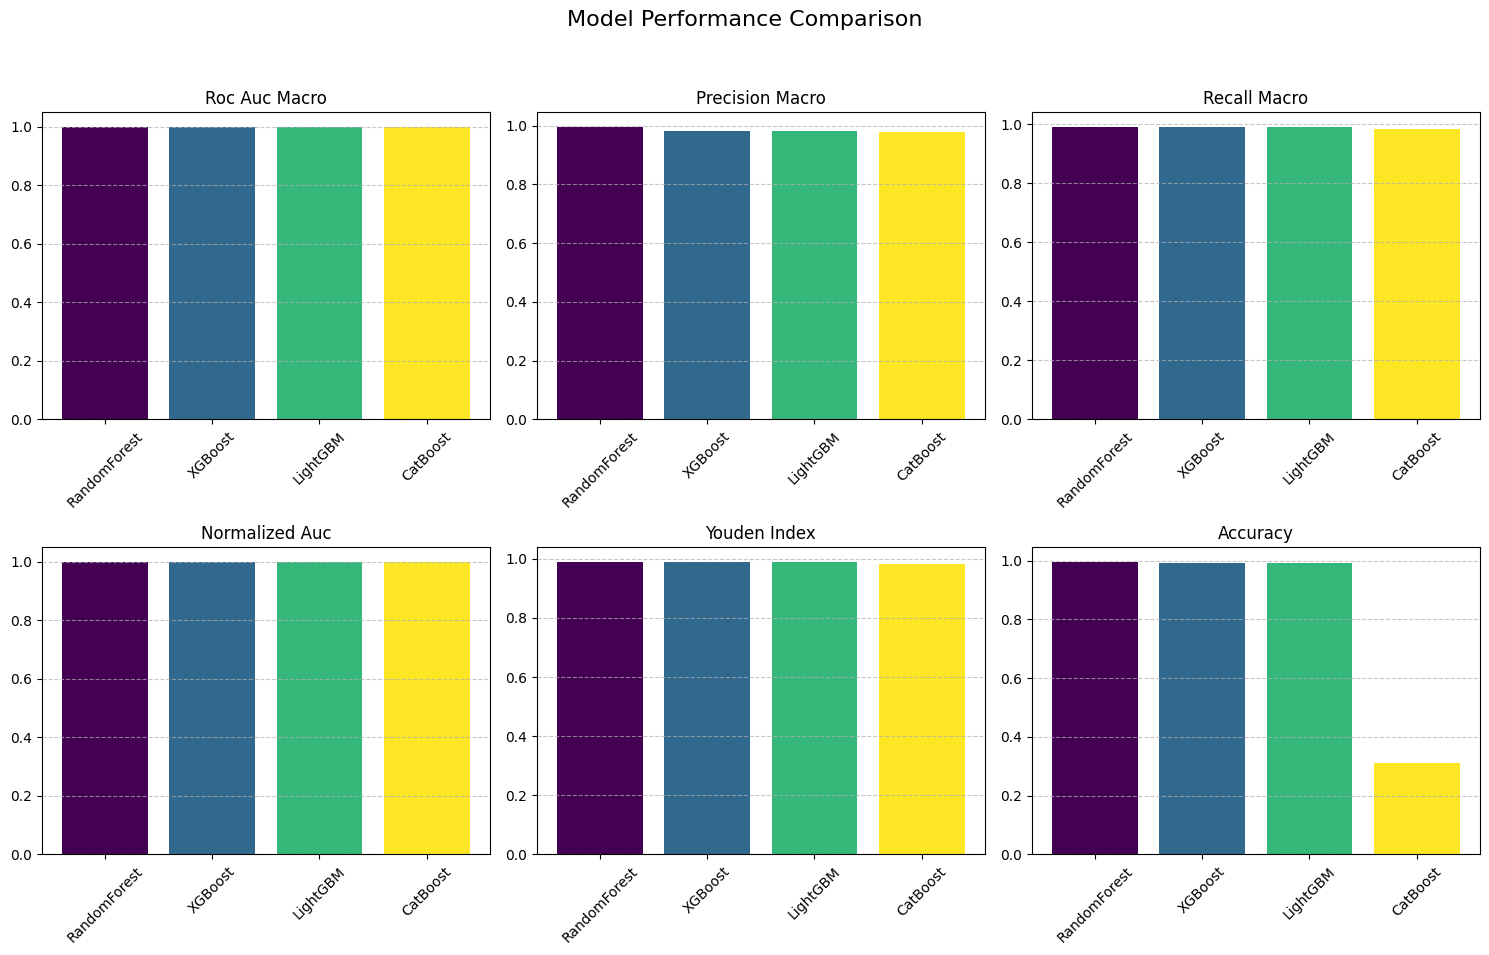

In [32]:
class MultiClassPredictiveMaintenanceEvaluator:
    """
    Comprehensive evaluator for multi-class predictive maintenance models.
    """

    def __init__(self, random_state=42):
        self.random_state = random_state
        self.models = {}
        self.results = {}

    def prepare_data(self, df, test_size=0.2, target_col='target'):
        """
        Prepare and split data, ensuring temporal sequence and correct data formats.
        """
        df['datetime'] = pd.to_datetime(df['datetime'])
        df = df.sort_values(by='datetime').reset_index(drop=True)

        exclude_cols = ['datetime', 'failure', 'target', '']
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        X = df[feature_cols].fillna(0)
        y = df[target_col]

        split_index = int(len(df) * (1 - test_size))
        X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
        y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

        # Convert y_train and y_test to 1D NumPy arrays to ensure compatibility
        y_train = y_train.values
        y_test = y_test.values

        print(f"Dataset shape: {df.shape}")
        print(f"Feature columns: {len(feature_cols)}")
        print(f"\nTrain set shape: {X_train.shape}")
        print(f"Test set shape: {X_test.shape}\n")

        return X_train, X_test, y_train, y_test

    def initialize_models(self):
        """
        Initialize all machine learning models.
        """
        self.models = {
            'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=self.random_state, n_jobs=-1),
            'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, random_state=self.random_state, eval_metric='mlogloss'),
            'LightGBM': LGBMClassifier(n_estimators=100, max_depth=6, random_state=self.random_state, verbose=-1),
            'CatBoost': CatBoostClassifier(iterations=500, depth=8, learning_rate=0.03,l2_leaf_reg=5, auto_class_weights="Balanced" ,random_seed=self.random_state, verbose=100)
        }

    def calculate_metrics(self, y_true, y_pred, y_pred_proba):
        """
        Calculate comprehensive metrics for multi-class classification.
        """
        metrics = {}
        classes = np.unique(y_true)
        
        # 1. ROC AUC (macro and micro)
        metrics['ROC_AUC_macro'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='macro')
        metrics['ROC_AUC_micro'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='micro')

        # 2. Normalized AUC
        per_class_aucs = [roc_auc_score(y_true == c, y_pred_proba[:, i]) for i, c in enumerate(classes)]
        metrics['Normalized_AUC'] = np.mean([(auc - 0.5) / 0.5 for auc in per_class_aucs])

        # 3. Youden Index
        youden_scores = []
        for i, c in enumerate(classes):
            y_true_binary = (y_true == c)
            y_pred_binary = (y_pred == c)
            tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            youden_scores.append(sensitivity + specificity - 1)
        metrics['Youden_Index'] = np.mean(youden_scores)
        
        # 4. Precision (macro and micro)
        metrics['Precision_macro'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
        metrics['Precision_micro'] = precision_score(y_true, y_pred, average='micro', zero_division=0)

        # 5. Recall (macro and micro)
        metrics['Recall_macro'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
        metrics['Recall_micro'] = recall_score(y_true, y_pred, average='micro', zero_division=0)
        
        metrics['Accuracy'] = np.mean(y_true == y_pred)
        return metrics

    def train_and_evaluate(self, X_train, X_test, y_train, y_test):
        """
        Train all models and evaluate their performance.
        """
        X_train.columns = [re.sub(r'[^A-Za-z0-9_]+', '', str(col)) for col in X_train.columns]
        X_test.columns = [re.sub(r'[^A-Za-z0-9_]+', '', str(col)) for col in X_test.columns]

        self.initialize_models()
        self.results = {}

        for model_name, model in self.models.items():
            print(f"Training {model_name}...")
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)
            metrics = self.calculate_metrics(y_test, y_pred, y_pred_proba)

            self.results[model_name] = {'metrics': metrics, 'y_pred': y_pred}
            print(f"{model_name} - ROC AUC (macro): {metrics['ROC_AUC_macro']:.4f}, Accuracy: {metrics['Accuracy']:.4f}")

    def print_detailed_results(self, y_test):
        """
        Print detailed classification reports and confusion matrices.
        """
        print("\n" + "="*80 + "\nDETAILED EVALUATION RESULTS\n" + "="*80)
        summary_data = [{'Model': name, **{k: f"{v:.4f}" for k, v in res['metrics'].items()}}
                        for name, res in self.results.items()]
        
        print("\nSUMMARY OF ALL METRICS:")
        print(pd.DataFrame(summary_data).to_string(index=False))

        for model_name, result in self.results.items():
            print(f"\n{'-'*60}\nDETAILED RESULTS FOR {model_name}\n{'-'*60}")
            print("Classification Report:\n", classification_report(y_test, result['y_pred']))
            print("Confusion Matrix:\n", confusion_matrix(y_test, result['y_pred']))

    def plot_results(self, figsize=(15, 10)):
        """
        Create and display visualizations of model performance.
        """
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('Model Performance Comparison', fontsize=16)
        axes = axes.ravel()
        
        metrics_to_plot = ['ROC_AUC_macro', 'Precision_macro', 'Recall_macro', 'Normalized_AUC', 'Youden_Index', 'Accuracy']
        model_names = list(self.results.keys())

        for i, metric in enumerate(metrics_to_plot):
            ax = axes[i]
            scores = [self.results[model]['metrics'][metric] for model in model_names]
            ax.bar(model_names, scores, color=plt.cm.viridis(np.linspace(0, 1, len(model_names))))
            ax.set_title(metric.replace('_', ' ').title())
            ax.tick_params(axis='x', labelrotation=45)
            ax.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()


def run_complete_evaluation(df):
    """
    Run the complete evaluation pipeline.
    """
    evaluator = MultiClassPredictiveMaintenanceEvaluator(random_state=42)
    X_train, X_test, y_train, y_test = evaluator.prepare_data(df)
    evaluator.train_and_evaluate(X_train, X_test, y_train, y_test)
    evaluator.print_detailed_results(y_test)
    evaluator.plot_results()
    return evaluator

# --- Main Execution ---
# df = pd.read_csv("../../data/azure_pm/balanced_dataset_safezone/merged_dataset/balanced_azure_pm.csv")
evaluator_results = run_complete_evaluation(df)

In [ ]:


# After training your models in MultiClassPredictiveMaintenanceEvaluator
# Save each model as a .pkl file

model_save_path = "../../../model/azure_pm/balanced_model/"

for model_name, model in evaluator_results.models.items():
    with open(f"{model_save_path}{model_name.lower()}.pkl", "wb") as f:
          pickle.dump(model, f)